Running worksheet test cases...
Softmax function passed the test case!
Predicted class labels: [1 1 0]
Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957
Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Cost function test passed!
Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Gradient test passed!
All worksheet test cases passed successfully!
Dataset loaded successfully.
Shape of X: (19999, 784)
Shape of y: (19999,)
Training set: (15999, 784) (15999,)
Testing set : (4000, 784) (4000,)


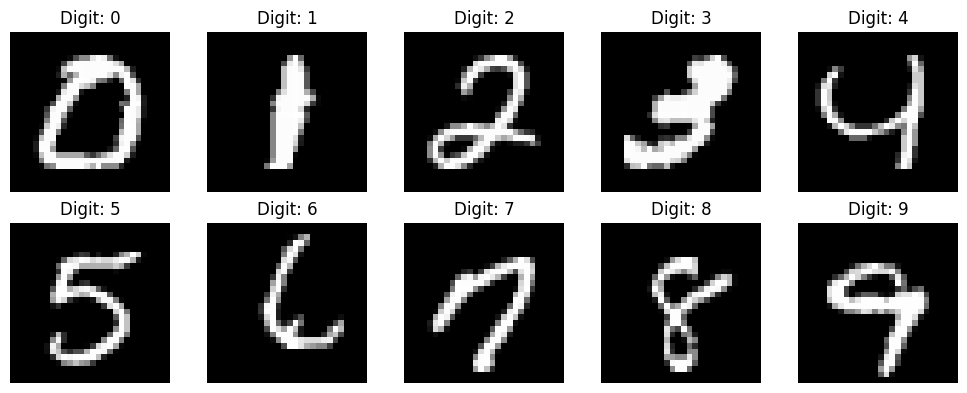


Question 1 Answer:
Extracting pixel values is a basic and useful first step, but it is not always sufficient for the best feature extraction.
Raw pixels preserve the image information, but they do not explicitly capture higher-level patterns such as edges, shapes, and spatial relationships.
For simple models like softmax regression, raw pixels can still work reasonably well on MNIST because the dataset is clean and standardized.
However, for more complex image tasks, better feature extraction methods such as convolutional neural networks usually give stronger performance.

Move forward: Dimension of feature matrix X and label vector y matched.
One-hot encoded y_train shape: (15999, 10)
One-hot encoded y_test shape : (4000, 10)

Training parameters:
Number of features: 784
Number of classes : 10
Learning rate     : 0.1
Iterations        : 1000
Iteration    0 | Cost: 2.220515
Iteration  100 | Cost: 0.600979
Iteration  200 | Cost: 0.480959
Iteration  300 | Cost: 0.430856
Iteration  400 |

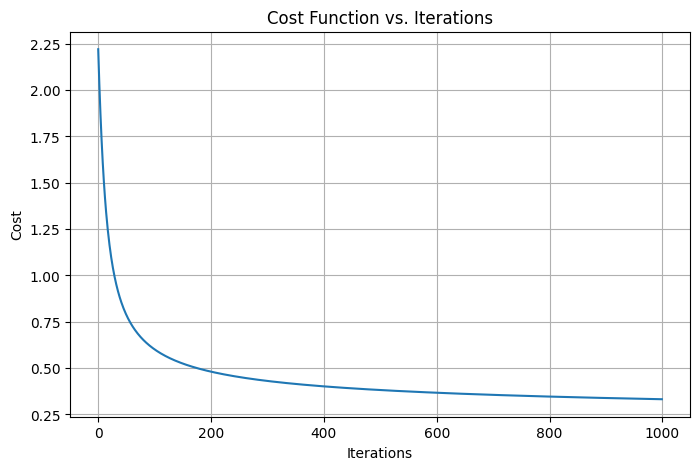


Model Evaluation
Accuracy : 0.9008
Precision: 0.9003
Recall   : 0.9008
F1-Score : 0.9001

Confusion Matrix:
[[385   0   1   0   1   2   0   0   2   1]
 [  0 440   1   0   1   3   0   0   4   0]
 [  5   4 342   6  11   1   9   6   5   9]
 [  0   2   6 362   0  13   2   2   8   9]
 [  0   4   7   1 347   0   6   0   3  17]
 [ 10   3   4  17   4 276   7   2  22   7]
 [  1   3   1   0   3   6 389   0   4   1]
 [  3   5   6   2   8   0   0 388   0  13]
 [  5  10   4   6   2  10   2   3 331   9]
 [  4   5   3  11  12   3   0  19   5 343]]


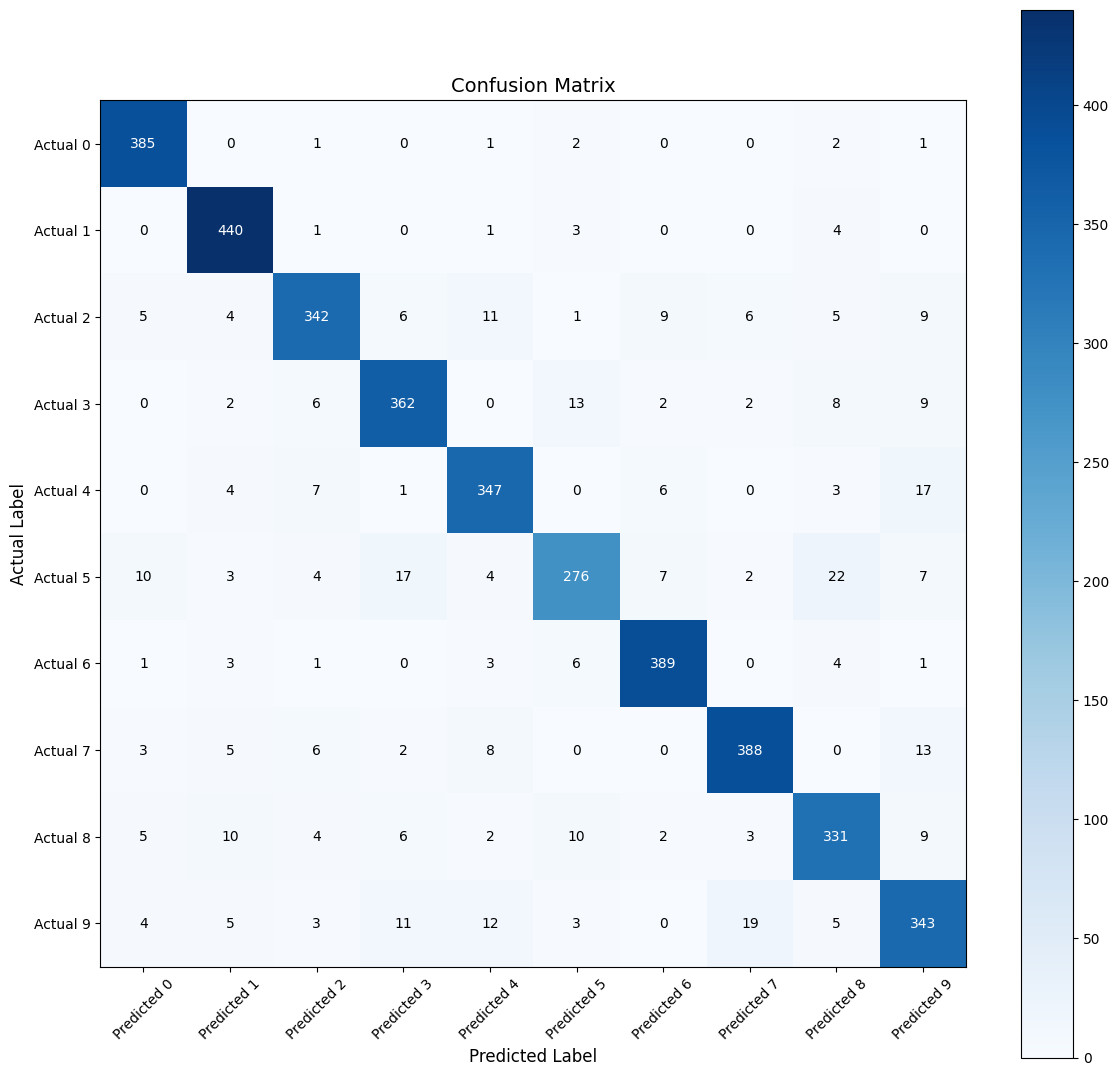

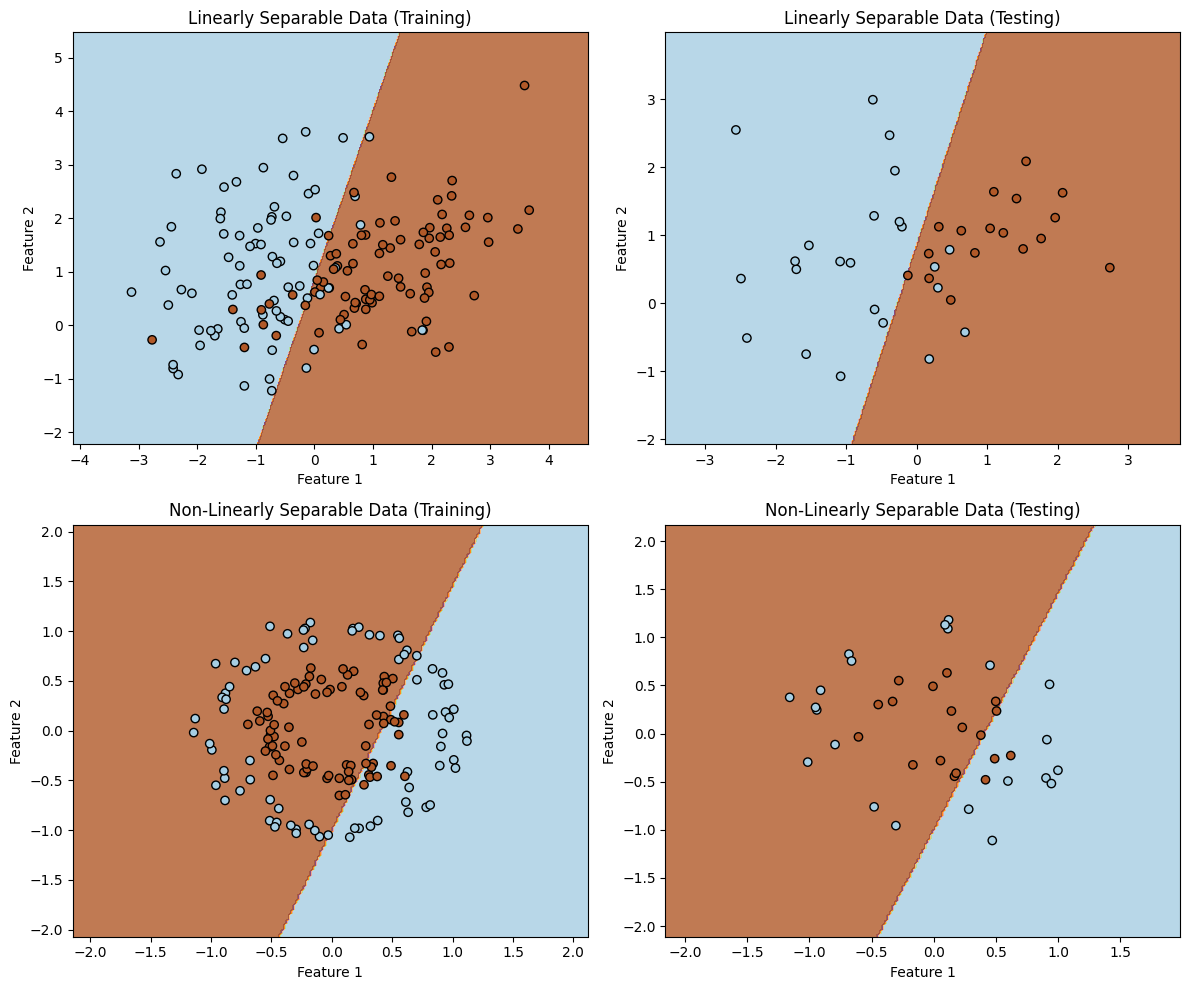


Question 2 Answer:
The logistic regression model performs well on the linearly separable dataset because the classes can be divided by a straight decision boundary.
However, its performance is weaker on the non-linearly separable circles dataset because logistic regression is a linear classifier.
This shows that linear models work well when class boundaries are approximately linear, but they struggle when the true class structure is curved or more complex.

Question 3 Answer:
Some challenges during implementation included handling matrix dimensions correctly, keeping the softmax computation numerically stable,
making sure the labels were one-hot encoded before training, and checking that gradients and parameter updates matched the mathematical formulas.
Another challenge was selecting a suitable learning rate and number of iterations so that the cost decreased smoothly during training.


In [2]:

# -----------------------------
# 1. Import libraries
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# -----------------------------
# 2. Softmax function
# -----------------------------
def softmax(z):
    """
    Compute softmax probabilities.

    Parameters:
        z (numpy.ndarray): shape (m, n)

    Returns:
        numpy.ndarray: shape (m, n)
    """
    z_stable = z - np.max(z, axis=1, keepdims=True)   # numerical stability
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# -----------------------------
# 3. Prediction function
# -----------------------------
def predict_softmax(X, W, b):
    """
    Predict class labels using softmax regression.

    Parameters:
        X (numpy.ndarray): shape (n, d)
        W (numpy.ndarray): shape (d, c)
        b (numpy.ndarray): shape (c,)

    Returns:
        numpy.ndarray: predicted labels shape (n,)
    """
    logits = np.dot(X, W) + b
    probs = softmax(logits)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes


# -----------------------------
# 4. Loss function
# -----------------------------
def loss_softmax(y_pred, y):
    """
    Compute average categorical cross-entropy loss.

    Parameters:
        y_pred (numpy.ndarray): predicted probabilities, shape (n, c) or (c,)
        y (numpy.ndarray): true one-hot labels, shape (n, c) or (c,)

    Returns:
        float
    """
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)

    # Handle both single-sample and multi-sample input
    if y_pred.ndim == 1:
        return -np.sum(y * np.log(y_pred))
    else:
        return -np.mean(np.sum(y * np.log(y_pred), axis=1))


# -----------------------------
# 5. Cost function
# -----------------------------
def cost_softmax(X, y, W, b):
    """
    Compute average softmax regression cost over all samples.

    Parameters:
        X (numpy.ndarray): shape (n, d)
        y (numpy.ndarray): shape (n, c)
        W (numpy.ndarray): shape (d, c)
        b (numpy.ndarray): shape (c,)

    Returns:
        float
    """
    logits = np.dot(X, W) + b
    y_pred = softmax(logits)
    total_loss = loss_softmax(y_pred, y)
    return total_loss


# -----------------------------
# 6. Gradient computation
# -----------------------------
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients with respect to W and b.

    Parameters:
        X (numpy.ndarray): shape (n, d)
        y (numpy.ndarray): shape (n, c)
        W (numpy.ndarray): shape (d, c)
        b (numpy.ndarray): shape (c,)

    Returns:
        grad_W, grad_b
    """
    n = X.shape[0]
    logits = np.dot(X, W) + b
    y_pred = softmax(logits)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b


# -----------------------------
# 7. Gradient descent
# -----------------------------
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent optimization.

    Parameters:
        X (numpy.ndarray): shape (n, d)
        y (numpy.ndarray): shape (n, c)
        W (numpy.ndarray): shape (d, c)
        b (numpy.ndarray): shape (c,)
        alpha (float): learning rate
        n_iter (int): number of iterations
        show_cost (bool): whether to print progress

    Returns:
        W, b, cost_history
    """
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i:4d} | Cost: {cost:.6f}")

    return W, b, cost_history


# -----------------------------
# 8. Plot sample images
# -----------------------------
def plot_sample_images(X, y):
    """
    Plot one sample image per digit class.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# -----------------------------
# 9. Load and prepare MNIST dataset
# -----------------------------
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Load MNIST CSV, split into train and test, and plot sample images.
    Assumes first column = label, remaining 784 columns = pixels.
    """
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values.astype(np.float32)

    # Normalize pixel values
    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print("Dataset loaded successfully.")
    print("Shape of X:", X.shape)
    print("Shape of y:", y.shape)
    print("Training set:", X_train.shape, y_train.shape)
    print("Testing set :", X_test.shape, y_test.shape)

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test


# -----------------------------
# 10. Evaluation function
# -----------------------------
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification using confusion matrix, precision, recall, F1, accuracy.
    """
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    return cm, precision, recall, f1, accuracy


# -----------------------------
# 11. Test cases from worksheet
# -----------------------------
print("========================================")
print("Running worksheet test cases...")
print("========================================")

# Softmax test
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

# Prediction test
X_test_case = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test_case = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test_case = np.array([0.1, 0.2, 0.3])

y_pred_test_case = predict_softmax(X_test_case, W_test_case, b_test_case)
assert y_pred_test_case.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test_case.shape}"
print("Predicted class labels:", y_pred_test_case)

# Loss test
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                           [0.1, 0.85, 0.05],
                           [0.05, 0.1, 0.85]])

y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                             [0.1, 0.05, 0.85],
                             [0.85, 0.1, 0.05]])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, but got "
    f"{loss_correct:.4f} >= {loss_incorrect:.4f}"
)
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

# Cost test
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Cost function test passed!")

# Gradient test
X_grad = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_grad = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_grad = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_grad = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_grad, y_grad, W_grad, b_grad)

z_manual = np.dot(X_grad, W_grad) + b_grad
y_pred_manual = softmax(z_manual)

grad_W_manual = np.dot(X_grad.T, (y_pred_manual - y_grad)) / X_grad.shape[0]
grad_b_manual = np.sum(y_pred_manual - y_grad, axis=0) / X_grad.shape[0]

assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)

print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Gradient test passed!")

print("All worksheet test cases passed successfully!")


# -----------------------------
# 12. Load dataset
# -----------------------------
# CHANGE THIS TO YOUR FILE NAME
csv_file = "/content/sample_data/mnist_train_small.csv"

X_train, X_test, y_train_raw, y_test_raw = load_and_prepare_mnist(csv_file)


# -----------------------------
# 13. Answer for Question 1
# -----------------------------
print("\nQuestion 1 Answer:")
print("Extracting pixel values is a basic and useful first step, but it is not always sufficient for the best feature extraction.")
print("Raw pixels preserve the image information, but they do not explicitly capture higher-level patterns such as edges, shapes, and spatial relationships.")
print("For simple models like softmax regression, raw pixels can still work reasonably well on MNIST because the dataset is clean and standardized.")
print("However, for more complex image tasks, better feature extraction methods such as convolutional neural networks usually give stronger performance.")


# -----------------------------
# 14. Shape check before training
# -----------------------------
assert len(X_train) == len(y_train_raw), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train_raw)}"
)
print("\nMove forward: Dimension of feature matrix X and label vector y matched.")


# -----------------------------
# 15. One-hot encode labels
# -----------------------------
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train_raw.reshape(-1, 1))
y_test = encoder.transform(y_test_raw.reshape(-1, 1))

print("One-hot encoded y_train shape:", y_train.shape)
print("One-hot encoded y_test shape :", y_test.shape)


# -----------------------------
# 16. Initialize parameters
# -----------------------------
d = X_train.shape[1]   # features
c = y_train.shape[1]   # classes

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

print("\nTraining parameters:")
print("Number of features:", d)
print("Number of classes :", c)
print("Learning rate     :", alpha)
print("Iterations        :", n_iter)


# -----------------------------
# 17. Train model
# -----------------------------
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)


# -----------------------------
# 18. Plot cost history
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.title("Cost Function vs. Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


# -----------------------------
# 19. Predict on test set
# -----------------------------
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1, accuracy = evaluate_classification(y_test_labels, y_pred_test)

print("\n========================================")
print("Model Evaluation")
print("========================================")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)


# -----------------------------
# 20. Plot confusion matrix
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)], rotation=45)
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()


# -----------------------------
# 21. Extra exercise:
#     Linear separability and logistic regression
# -----------------------------
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split the data
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split the data
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(
    axes[0, 0],
    logistic_model_linear_separable,
    X_train_linear,
    y_train_linear,
    'Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[0, 1],
    logistic_model_linear_separable,
    X_test_linear,
    y_test_linear,
    'Linearly Separable Data (Testing)'
)

plot_decision_boundary(
    axes[1, 0],
    logistic_model_non_linear_separable,
    X_train_non_linear,
    y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[1, 1],
    logistic_model_non_linear_separable,
    X_test_non_linear,
    y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()


# -----------------------------
# 22. Answers for Question 2 and Question 3
# -----------------------------
print("\nQuestion 2 Answer:")
print("The logistic regression model performs well on the linearly separable dataset because the classes can be divided by a straight decision boundary.")
print("However, its performance is weaker on the non-linearly separable circles dataset because logistic regression is a linear classifier.")
print("This shows that linear models work well when class boundaries are approximately linear, but they struggle when the true class structure is curved or more complex.")

print("\nQuestion 3 Answer:")
print("Some challenges during implementation included handling matrix dimensions correctly, keeping the softmax computation numerically stable,")
print("making sure the labels were one-hot encoded before training, and checking that gradients and parameter updates matched the mathematical formulas.")
print("Another challenge was selecting a suitable learning rate and number of iterations so that the cost decreased smoothly during training.")
